In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import os

import plot_config

from pathlib import Path

In [2]:
SUBJECT_ID = "sub-NDARINVAG388HJL"
FILE_SUFFIX = "_task-hammerAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5"

# FILE_DIR = Path("/cluster/work/ianpe/masters_thesis/preprocessing/tcp/parcellations") # IDUN
FILE_DIR = Path("/Users/ipeglin/Documents/masters_thesis/preprocessing/tcp/parcellations") # LOCAL
FILE_PATH = FILE_DIR / SUBJECT_ID / f"{SUBJECT_ID}{FILE_SUFFIX}"

ROI_IDX = 2 # lAMY-rh

In [3]:
SAVE_DIR = Path("/Users/ipeglin/LaTeX/masters_thesis/Images/pipeline")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
with h5py.File(FILE_PATH, 'r') as f:
  mvmd_group = f['mvmd']
  wb_group = mvmd_group['whole-band']
  
  num_iterations = wb_group.attrs.get("num_iterations", None)
  
  modes = np.asarray(wb_group['modes'])
  num_modes, num_channels, num_samples = modes.shape
  
  center_freqs = np.asarray(wb_group['center_frequencies'])
  freq_traces = np.asarray(wb_group['frequency_traces'])
  

/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_26798/522395179.py:15: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(num_rows, num_cols, figsize=(7.0, 1.5 * num_rows), sharex=True)


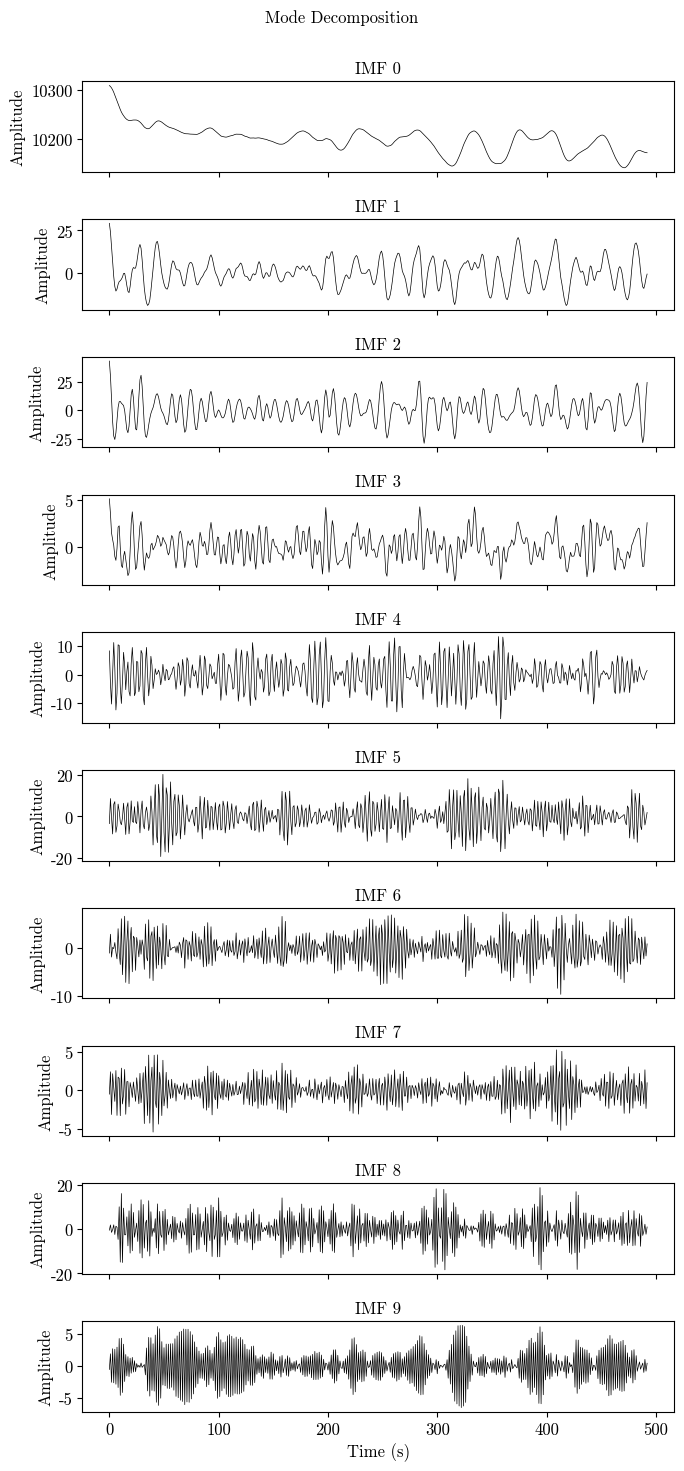

In [5]:
import math

# Set font size to 12 for LaTeX (no scaling issues if width is set to typical \linewidth)
plt.rcParams.update({'font.size': 12})

# plotting first ROI
ROI_IDX = 0

# Revert to 1 column to maximize the horizontal resolution limit of a standard page
num_cols = 1
num_rows = num_modes

# A width of 7.0 inches is standard for \linewidth. 
# We reduce the height per plot slightly to avoid the figure becoming too tall overall.
fig, ax = plt.subplots(num_rows, num_cols, figsize=(7.0, 1.5 * num_rows), sharex=True)

# Ensure ax is an iterable array
axes = np.atleast_1d(ax)

fig.suptitle("Mode Decomposition")

for i in range(num_modes):
    # Set traces to black, and make the line thinner (e.g., 0.5) to untangle high-frequency oscillations
    axes[i].plot(modes[i, ROI_IDX, :], color='k', linewidth=0.5)
    axes[i].set_ylabel("Amplitude")
    axes[i].set_title(f"IMF {i}")

# Only set the x-label on the bottom-most plot
axes[-1].set_xlabel("Time (s)")

# Use tight_layout with padding to remove wedge margins while dodging the super title
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(SAVE_DIR / "timeseries_modes.pdf")